<a href="https://colab.research.google.com/github/DaveD-BU/DX-703-FinalProject/blob/main/Milestone_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Milestone Two

**Data Preparation and Model Exploration**
**Due:** Midnight on November 16th with usual 2-hour grace period — **worth 100 points**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




### Load Data

In [1]:
# Your code here; add as many cells as you need but make it clear what the structure is.
# Reload the huffpoast dataset
from datasets import load_dataset, DatasetDict
from collections import Counter
import numpy as np
import pandas as pd

# Set random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)

# Load HuffPost dataset from JSON
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")
print(f"Total samples: {len(huff_all)}")
print(f"Features: {huff_all.column_names}")

# Display example entry
print("\nEntry example:")
example = huff_all[0]
for key, value in example.items():
    display_value = str(value)[:100] + "..." if len(str(value)) > 100 else value
    print(f"  {key}: {display_value}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total samples: 200853
Features: ['category', 'headline', 'authors', 'link', 'short_description', 'date']

Entry example:
  category: CRIME
  headline: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors: Melissa Jeltsen
  link: https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89
  short_description: She left her husband. He killed their children. Just another day in America.
  date: 2018-05-26 00:00:00


### Apply Cleaning and Normalization

In [2]:
# Remove samples with missing headlines (we found 6 in Milestone 1)
# Filter out samples with missing or empty headlines
initial_count = len(huff_all)
huff_cleaned = huff_all.filter(lambda ex: ex['headline'] and ex['headline'].strip())

removed_count = initial_count - len(huff_cleaned)
print(f"Samples before: {initial_count}")
print(f"Samples after: {len(huff_cleaned)}")
print(f"Removed: {removed_count} samples with missing headlines")

Samples before: 200853
Samples after: 200847
Removed: 6 samples with missing headlines


In [3]:
# Remove duplicate samples (identified 488 in Milestone 1)
# Create combined text for duplicate detection
def create_combined_text(example):
    headline = example['headline'] or ""
    description = example['short_description'] or ""
    return headline + " [SEP] " + description

# Track seen texts and filter duplicates
seen_texts = set()
def is_not_duplicate(example):
    combined = create_combined_text(example)
    if combined in seen_texts:
        return False
    seen_texts.add(combined)
    return True

initial_count = len(huff_cleaned)
huff_cleaned = huff_cleaned.filter(is_not_duplicate)

removed_count = initial_count - len(huff_cleaned)
print(f"Samples before: {initial_count}")
print(f"Samples after: {len(huff_cleaned)}")
print(f"Removed: {removed_count} duplicate samples")

Samples before: 200847
Samples after: 200363
Removed: 484 duplicate samples


In [4]:
# Merge overlapping categories that we identified

# Define label merging map
label_merge_map = {
    'ARTS': 'ARTS',
    'ARTS & CULTURE': 'ARTS',
    'CULTURE & ARTS': 'ARTS',
    'WORLDPOST': 'WORLDPOST',
    'THE WORLDPOST': 'WORLDPOST',
    'WELLNESS': 'WELLNESS',
    'HEALTHY LIVING': 'WELLNESS',
    'PARENTS': 'PARENTING',
    'PARENTING': 'PARENTING',
    'STYLE': 'STYLE',
    'STYLE & BEAUTY': 'STYLE'
}

# Apply label merging
def merge_labels(example):
    original_label = example['category']
    merged_label = label_merge_map.get(original_label, original_label)
    example['category'] = merged_label
    return example

print("Label Merging Map:")
merged_pairs = {k: v for k, v in label_merge_map.items() if k != v}
for original, merged in sorted(merged_pairs.items()):
    print(f"  {original} -> {merged}")
print()

huff_cleaned = huff_cleaned.map(merge_labels)

# Verify merging
unique_categories = sorted(set(huff_cleaned['category']))
print(f"Categories after merging: {len(unique_categories)}")
print(f"Categories reduced from 41 to {len(unique_categories)}")

Label Merging Map:
  ARTS & CULTURE -> ARTS
  CULTURE & ARTS -> ARTS
  HEALTHY LIVING -> WELLNESS
  PARENTS -> PARENTING
  STYLE & BEAUTY -> STYLE
  THE WORLDPOST -> WORLDPOST

Categories after merging: 35
Categories reduced from 41 to 35


In [5]:
# Concatenate headline and short_description with [SEP] token

def add_combined_text(example):
    headline = (example['headline'] or "").strip()
    description = (example['short_description'] or "").strip()

    # Combine with [SEP] token
    combined = f"{headline} [SEP] {description}"
    example['text'] = combined

    return example

huff_cleaned = huff_cleaned.map(add_combined_text)

print("Added 'text' field combining headline and description")
print("\nExample of combined texts:")
for i in range(3):
    print(f"\n{i+1}. Category: {huff_cleaned[i]['category']}")
    print(f"   Text: {huff_cleaned[i]['text'][:150]}...")

Added 'text' field combining headline and description

Example of combined texts:

1. Category: CRIME
   Text: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV [SEP] She left her husband. He killed their children. Just another day in America....

2. Category: ENTERTAINMENT
   Text: Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song [SEP] Of course it has a song....

3. Category: ENTERTAINMENT
   Text: Hugh Grant Marries For The First Time At Age 57 [SEP] The actor and his longtime girlfriend Anna Eberstein tied the knot in a civil ceremony....


In [6]:
# Normalize the text (lowercase and stripping any whitespace)
def normalize_text(example):
    text = example['text']

    # Convert to lowercase
    text = text.lower()

    # Strip extra whitespace
    text = ' '.join(text.split())
    example['text'] = text
    return example

huff_cleaned = huff_cleaned.map(normalize_text)

print("Applied text normalization:")
print("  - Converted to lowercase")
print("  - Stripped extra whitespace")
print("\nNormalized Text Example:")
print(f"  {huff_cleaned[0]['text'][:200]}...")

Applied text normalization:
  - Converted to lowercase
  - Stripped extra whitespace

Normalized Text Example:
  there were 2 mass shootings in texas last week, but only 1 on tv [sep] she left her husband. he killed their children. just another day in america....


In [7]:
# Convert category strings to integer labels

# Get sorted unique categories
categories = sorted(set(huff_cleaned['category']))
num_classes = len(categories)

# Create label mapping
label2id = {label: idx for idx, label in enumerate(categories)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"Number of classes: {num_classes}")
print("\nLabel Mapping (Only first 10):")
for i, (label, idx) in enumerate(list(label2id.items())[:10]):
    print(f"  {idx}: {label}")
print("  ...")
print()

# Add integer label to dataset
def add_label_id(example):
    example['label'] = label2id[example['category']]
    return example

huff_cleaned = huff_cleaned.map(add_label_id)
print("Added 'label' field with integer encoding")

Number of classes: 35

Label Mapping (Only first 10):
  0: ARTS
  1: BLACK VOICES
  2: BUSINESS
  3: COLLEGE
  4: COMEDY
  5: CRIME
  6: DIVORCE
  7: EDUCATION
  8: ENTERTAINMENT
  9: ENVIRONMENT
  ...

Added 'label' field with integer encoding


In [8]:
print(huff_cleaned)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date', 'text', 'label'],
    num_rows: 200363
})


In [9]:
# Calculate class weights to handle 9.6:1 imbalance ratio

from collections import Counter

# Count samples per class
label_counts = Counter(huff_cleaned['label'])
total_samples = len(huff_cleaned)

# Compute class weights: total_samples / (num_classes * samples_in_class)
class_weights = {}
for label_id in range(num_classes):
    count = label_counts[label_id]
    weight = total_samples / (num_classes * count)
    class_weights[label_id] = weight

print(f"Total samples: {total_samples}")
print(f"Number of classes: {num_classes}")
print("\nClass Weights (top 5 highest weights - minority classes):")
sorted_weights = sorted(class_weights.items(), key=lambda x: x[1], reverse=True)
for label_id, weight in sorted_weights[:5]:
    category = id2label[label_id]
    count = label_counts[label_id]
    print(f"  {category}: weight={weight:.3f} (n={count})")

print("\nClass Weights (top 5 lowest weights - majority classes):")
for label_id, weight in sorted_weights[-5:]:
    category = id2label[label_id]
    count = label_counts[label_id]
    print(f"  {category}: weight={weight:.3f} (n={count})")

Total samples: 200363
Number of classes: 35

Class Weights (top 5 highest weights - minority classes):
  EDUCATION: weight=5.702 (n=1004)
  LATINO VOICES: weight=5.071 (n=1129)
  COLLEGE: weight=5.004 (n=1144)
  ENVIRONMENT: weight=4.330 (n=1322)
  GOOD NEWS: weight=4.095 (n=1398)

Class Weights (top 5 lowest weights - majority classes):
  STYLE: weight=0.487 (n=11761)
  PARENTING: weight=0.456 (n=12546)
  ENTERTAINMENT: weight=0.357 (n=16054)
  WELLNESS: weight=0.234 (n=24510)
  POLITICS: weight=0.175 (n=32721)


### Reproducable Splits

In [10]:
# Split data into 70% train, 15% validation, 15% test with stratification
# putting this here before tokenization to avoid data leakage

# Import train test split
from sklearn.model_selection import train_test_split

# Extract labels for stratification
all_labels = huff_cleaned['label']

# Create indices for splitting
indices = list(range(len(huff_cleaned)))

# First split: 70% train, 30% temp (for val+test)
train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=random_seed,
    stratify=all_labels
)

# Second split: Split temp into 50% val, 50% test (15% each of total)
temp_labels = [all_labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=random_seed,
    stratify=temp_labels
)

# Create dataset splits
train_data = huff_cleaned.select(train_indices)
val_data = huff_cleaned.select(val_indices)
test_data = huff_cleaned.select(test_indices)

print(f"Total samples: {len(huff_cleaned)}")
print(f"\nTrain set: {len(train_data)} samples ({len(train_data)/len(huff_cleaned)*100:.1f}%)")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/len(huff_cleaned)*100:.1f}%)")
print(f"Test set: {len(test_data)} samples ({len(test_data)/len(huff_cleaned)*100:.1f}%)")
print()

# Verify stratification
train_label_dist = Counter(train_data['label'])
val_label_dist = Counter(val_data['label'])
test_label_dist = Counter(test_data['label'])

print("Verify stratification (sample category distributions):")
sample_categories = ['POLITICS', 'WELLNESS', 'ARTS', 'EDUCATION']
for cat in sample_categories:
    if cat in label2id:
        label_id = label2id[cat]
        train_pct = train_label_dist[label_id] / len(train_data) * 100
        val_pct = val_label_dist[label_id] / len(val_data) * 100
        test_pct = test_label_dist[label_id] / len(test_data) * 100
        print(f"  {cat}:")
        print(f"    Train: {train_pct:.2f}% | Val: {val_pct:.2f}% | Test: {test_pct:.2f}%")

Total samples: 200363

Train set: 140254 samples (70.0%)
Validation set: 30054 samples (15.0%)
Test set: 30055 samples (15.0%)

Verify stratification (sample category distributions):
  POLITICS:
    Train: 16.33% | Val: 16.33% | Test: 16.33%
  WELLNESS:
    Train: 12.23% | Val: 12.23% | Test: 12.23%
  ARTS:
    Train: 1.93% | Val: 1.93% | Test: 1.94%
  EDUCATION:
    Train: 0.50% | Val: 0.50% | Test: 0.50%


In [11]:
# Build vocabulary and create tokenization layer
# Adapt vocabulary on training data ONLY to prevent data leakage

# Import tensorflow and keras text vectorization
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Based on Milestone 1 analysis: 95th percentile is 56 words
# Using max_length of 128 tokens provides comfortable headroom
# All samples fit within this length (100% coverage at 300 tokens)
MAX_TOKENS = 20000  # Vocab size
MAX_LENGTH = 128    # Sequence length (covers all samples with room to spare)

# Create TextVectorization layer
vectorize_layer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LENGTH,
    standardize=None # Putting "None" here as we already did text normalization
)

# Adapt vocabulary on training data ONLY (prevents leakage)
print("Adapting vocabulary on training data only:")
train_texts = train_data['text']
vectorize_layer.adapt(train_texts)

vocab_size = len(vectorize_layer.get_vocabulary())
print(f"\nVocabulary size: {vocab_size}")
print(f"Max sequence length: {MAX_LENGTH} tokens")
print(f"Coverage: Based on Milestone 1, this covers 100% of samples")
print()

print("First 30 tokens in vocabulary:")
vocab = vectorize_layer.get_vocabulary()
print(vocab[:30])
print()

# Test vectorization on a sample
sample_text = train_data[0]['text']
vectorized = vectorize_layer([sample_text])
non_padding = tf.reduce_sum(tf.cast(vectorized[0] != 0, tf.int32)).numpy()

print("Vectorization Example:")
print(f"Original text: {sample_text[:120]}...")
print(f"Vectorized shape: {vectorized.shape}")
print(f"Non-padding tokens: {non_padding}/{MAX_LENGTH}")
print(f"First 30 tokens: {vectorized[0, :30].numpy()}")

Adapting vocabulary on training data only:

Vocabulary size: 20000
Max sequence length: 128 tokens
Coverage: Based on Milestone 1, this covers 100% of samples

First 30 tokens in vocabulary:
['', '[UNK]', np.str_('the'), np.str_('[sep]'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('and'), np.str_('in'), np.str_('is'), np.str_('for'), np.str_('that'), np.str_('on'), np.str_('you'), np.str_('with'), np.str_('i'), np.str_('are'), np.str_('it'), np.str_('your'), np.str_('this'), np.str_('be'), np.str_('we'), np.str_('as'), np.str_('at'), np.str_('from'), np.str_('have'), np.str_('not'), np.str_('about'), np.str_('was'), np.str_('but')]

Vectorization Example:
Original text: here's a first look at 'sorry to bother you' starring lakeith stanfield [sep] the movie hits theaters this summer....
Vectorized shape: (1, 128)
Non-padding tokens: 19/128
First 30 tokens: [ 203    5   77  126   23    1    4 8743 5864 4301    1    1    3    2
  461 1373 5944   19 4492    0    0    0    0    0  

In [12]:
# Convert to tf.data.Dataset for efficient training with batching, padding/truncation, and prefetching
# Batch size for A100 GPU
BATCH_SIZE = 64
# Convert HuggingFace dataset to tf.data.Dataset with:
#     - Vectorization (tokenization + padding/truncation to MAX_LENGTH)
#     - Batching
#     - Shuffling (for training only)
#     - Prefetching for performance
def create_tf_dataset(hf_dataset, batch_size, shuffle=False):

    # Extract texts and labels as Python lists
    texts = list(hf_dataset['text'])
    labels = list(hf_dataset['label'])

    # Create tf.data.Dataset from lists
    dataset = tf.data.Dataset.from_tensor_slices((texts, labels))

    # Shuffle if training (buffer size = 10k samples)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000, seed=random_seed)

    # Batch the data
    dataset = dataset.batch(batch_size)


    # Vectorize the text (applies padding/truncation automatically)
    dataset = dataset.map(
        lambda x, y: (vectorize_layer(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Prefetch for performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Create datasets
print("-- Creating TensorFlow datasets --")
train_dataset = create_tf_dataset(train_data, BATCH_SIZE, shuffle=True)
val_dataset = create_tf_dataset(val_data, BATCH_SIZE, shuffle=False)
test_dataset = create_tf_dataset(test_data, BATCH_SIZE, shuffle=False)

num_train_batches = len(train_data) // BATCH_SIZE + (1 if len(train_data) % BATCH_SIZE else 0)
num_val_batches = len(val_data) // BATCH_SIZE + (1 if len(val_data) % BATCH_SIZE else 0)
num_test_batches = len(test_data) // BATCH_SIZE + (1 if len(test_data) % BATCH_SIZE else 0)

print(f"\nTrain dataset: {len(train_data)} samples, {num_train_batches} batches")
print(f"Validation dataset: {len(val_data)} samples, {num_val_batches} batches")
print(f"Test dataset: {len(test_data)} samples, {num_test_batches} batches")
print()

# Verify batch shapes
print("Verifying batch shapes:")
for texts_batch, labels_batch in train_dataset.take(1):
    print(f"  Text batch shape: {texts_batch.shape} (batch_size, max_length)")
    print(f"  Label batch shape: {labels_batch.shape}")

    # Show one example from the batch
    non_padding = tf.reduce_sum(tf.cast(texts_batch[0] != 0, tf.int32)).numpy()
    print(f"\n  Example from batch:")
    print(f"    Vectorized text (first 30 tokens): {texts_batch[0, :30].numpy()}")
    print(f"    Non-padding tokens: {non_padding}/{MAX_LENGTH}")
    print(f"    Label: {labels_batch[0].numpy()} ({id2label[labels_batch[0].numpy()]})")

-- Creating TensorFlow datasets --

Train dataset: 140254 samples, 2192 batches
Validation dataset: 30054 samples, 470 batches
Test dataset: 30055 samples, 470 batches

Verifying batch shapes:
  Text batch shape: (64, 128) (batch_size, max_length)
  Label batch shape: (64,)

  Example from batch:
    Vectorized text (first 30 tokens): [18967  1110  2658  5269   506    46  8439  2618    93     3  1644    33
   589     1   213   304     0     0     0     0     0     0     0     0
     0     0     0     0     0     0]
    Non-padding tokens: 16/128
    Label: 19 (PARENTING)


In [13]:
# Ensuring that padding and truncation work
# Import random
import random

# Find a short text and a long text
text_lengths = [len(text.split()) for text in train_data['text']]
shortest_idx = int(np.argmin(text_lengths))  # Convert to Python int
longest_idx = int(np.argmax(text_lengths))    # Convert to Python int

print("Short Text Example (will be padded):")
short_text = train_data[shortest_idx]['text']
short_vec = vectorize_layer([short_text])
non_padding_short = tf.reduce_sum(tf.cast(short_vec[0] != 0, tf.int32)).numpy()
print(f"  Original: {short_text}")
print(f"  Word count: {len(short_text.split())} words")
print(f"  Non-padding tokens: {non_padding_short}/{MAX_LENGTH}")
print(f"  Vectorized (first 20 tokens): {short_vec[0, :20].numpy()}")
print()

print("Long Text Example (may be truncated if > 128 tokens):")
long_text = train_data[longest_idx]['text']
long_vec = vectorize_layer([long_text])
non_padding_long = tf.reduce_sum(tf.cast(long_vec[0] != 0, tf.int32)).numpy()
print(f"  Original: {long_text[:200]}...")
print(f"  Full text length: {len(long_text)} characters")
print(f"  Word count: {len(long_text.split())} words")
print(f"  Non-padding tokens: {non_padding_long}/{MAX_LENGTH}")
if non_padding_long == MAX_LENGTH:
    print(f"  NOTE: Text was truncated to MAX_LENGTH={MAX_LENGTH}")
else:
    print(f"  NOTE: Text fit within MAX_LENGTH (no truncation needed)")
print()

# Show distribution of sequence lengths after vectorization
print("Show Sequence Length Distribution After Vectorization):")
sample_size = min(1000, len(train_data))
sample_indices = random.sample(range(len(train_data)), sample_size)
seq_lengths = []

for idx in sample_indices:
    text = train_data[idx]['text']
    vec = vectorize_layer([text])
    non_padding = tf.reduce_sum(tf.cast(vec[0] != 0, tf.int32)).numpy()
    seq_lengths.append(non_padding)

seq_lengths = np.array(seq_lengths)
print(f"  Mean sequence length: {np.mean(seq_lengths):.1f} tokens")
print(f"  Median: {np.median(seq_lengths):.0f} tokens")
print(f"  95th percentile: {np.percentile(seq_lengths, 95):.0f} tokens")
print(f"  Max: {np.max(seq_lengths):.0f} tokens")
print(f"  Samples at MAX_LENGTH: {np.sum(seq_lengths == MAX_LENGTH)} ({np.sum(seq_lengths == MAX_LENGTH)/len(seq_lengths)*100:.2f}%)")

Short Text Example (will be padded):
  Original: hellraiser-7 [sep]
  Word count: 2 words
  Non-padding tokens: 2/128
  Vectorized (first 20 tokens): [1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Long Text Example (may be truncated if > 128 tokens):
  Original: weekend roundup: laughing at god [sep] the first principle of an open society is not to let the intolerant define "the territory of insult" -- those areas off limits to criticism or ridicule. but how ...
  Full text length: 1428 characters
  Word count: 228 words
  Non-padding tokens: 128/128
  NOTE: Text was truncated to MAX_LENGTH=128

Show Sequence Length Distribution After Vectorization):
  Mean sequence length: 30.5 tokens
  Median: 29 tokens
  95th percentile: 56 tokens
  Max: 117 tokens
  Samples at MAX_LENGTH: 0 (0.00%)


### Preprocessing Examples

In [14]:
# Show complete examples after all preprocessing steps
print("\nShowing 5 random samples from each split to verify preprocessing:\n")

# Function to display examples
def display_preprocessed_examples(dataset, split_name, num_samples=5):
    print(f"\n{split_name.upper()} SET EXAMPLES:")
    print("-" * 80)

    sample_indices = random.sample(range(len(dataset)), num_samples)

    for i, idx in enumerate(sample_indices, 1):
        example = dataset[idx]

        # Vectorize the text
        vectorized = vectorize_layer([example['text']])
        non_padding = tf.reduce_sum(tf.cast(vectorized[0] != 0, tf.int32)).numpy()

        print(f"\n{i}. CATEGORY: {example['category']} (label={example['label']})")
        print(f"   ORIGINAL TEXT: {example['text'][:150]}...")
        print(f"   TEXT LENGTH: {len(example['text'].split())} words")
        print(f"   VECTORIZED LENGTH: {non_padding}/{MAX_LENGTH} tokens (padding: {MAX_LENGTH - non_padding})")
        print(f"   FIRST 20 TOKENS: {vectorized[0, :20].numpy()}")

# Display examples from each split
display_preprocessed_examples(train_data, "Training", num_samples=3)
display_preprocessed_examples(val_data, "Validation", num_samples=3)
display_preprocessed_examples(test_data, "Test", num_samples=3)



Showing 5 random samples from each split to verify preprocessing:


TRAINING SET EXAMPLES:
--------------------------------------------------------------------------------

1. CATEGORY: POLITICS (label=20)
   ORIGINAL TEXT: this is not government. it's savagery. [sep] i want to move to hawaii solely to be able to vote for sen. hirono. if every elected official had to take...
   TEXT LENGTH: 32 words
   VECTORIZED LENGTH: 32/128 tokens (padding: 96)
   FIRST 20 TOKENS: [  19    9   26 5693   50    1    3   15   87    4  422    4 2700 8614
    4   20  546    4  535   10]

2. CATEGORY: SCIENCE (label=23)
   ORIGINAL TEXT: 'peking man' was sophisticated & meticulous about clothing, artifacts suggest [sep] perhaps the strangest finding was evidence for "drilling." shen ex...
   TEXT LENGTH: 29 words
   VECTORIZED LENGTH: 29/128 tokens (padding: 99)
   FIRST 20 TOKENS: [    1  8058    28  5949   220     1    27 14495 15648  2422     3   876
     2  8604   725    28  1134    10     1     1]


In [15]:
# Important variables
key_vars = f"""
Datasets:
- train_dataset: TensorFlow dataset for training ({len(train_data)} samples)
- val_dataset: TensorFlow dataset for validation ({len(val_data)} samples)
- test_dataset: TensorFlow dataset for testing ({len(test_data)} samples)

Preprocessing:
- vectorize_layer: TextVectorization layer
- vocab_size: {vocab_size}
- MAX_LENGTH: {MAX_LENGTH} (sequence length)
- BATCH_SIZE: {BATCH_SIZE}

Lables:
- num_classes: {num_classes} (number of output classes)
- label2id: Dictionary mapping category names to integers
- id2label: Dictionary mapping integers to category names
- class_weights: Dictionary of class weights for imbalanced training

Random Seed:
- random_seed: {random_seed} (use for all model initialization)
"""

print(key_vars)


Datasets:
- train_dataset: TensorFlow dataset for training (140254 samples)
- val_dataset: TensorFlow dataset for validation (30054 samples)
- test_dataset: TensorFlow dataset for testing (30055 samples)

Preprocessing:
- vectorize_layer: TextVectorization layer
- vocab_size: 20000
- MAX_LENGTH: 128 (sequence length)
- BATCH_SIZE: 64

Lables:
- num_classes: 35 (number of output classes)
- label2id: Dictionary mapping category names to integers
- id2label: Dictionary mapping integers to category names
- class_weights: Dictionary of class weights for imbalanced training

Random Seed:
- random_seed: 42 (use for all model initialization)



Preprocessing Summary:

1. Data Loaded:
   - Dataset: HuffPost News Category Dataset
   - Source: Hugging Face (khalidalt/HuffPost)
   - Initial samples: 200,853
   - Initial classes: 41

2. Data Cleaning
   
   a) Removed Missing Headlines:
      - Samples removed: 6
      - Reason: Headlines are critical for classification
      
   b) Removed Duplicates:
      - Samples removed: 484
      - Method: Hash-based deduplication on combined text
      - Reason: Prevent data leakage and overfitting

3. Label Consolidation:
   - Merged overlapping categories:
     * ARTS + ARTS & CULTURE + CULTURE & ARTS → ARTS
     * WORLDPOST + THE WORLDPOST → WORLDPOST
     * WELLNESS + HEALTHY LIVING → WELLNESS
     * PARENTS + PARENTING → PARENTING
     * STYLE + STYLE & BEAUTY → STYLE
   - Classes after merging: 35 (reduced from 41)
   - Rationale: Reduce confusion and increase minority class samples

4. Text Processing:
   
   a) Combined Fields:
      - Format: "headline [SEP] short_description"
      - Missing descriptions handled: Used headline only with empty string
      
   b) Normalization:
      - Converted to lowercase
      - Stripped extra whitespace
      - Standardized formatting

5. Label Encoding:
   - Created integer labels: 0-34 (35 classes)
   - Maintained label-to-name mapping (id2label, label2id)

6. Class Imbalance:
   - Computed class weights using formula: total_samples / (num_classes * class_count)
   - Imbalance ratio: 9.6:1 (max/median)
   - Highest weight: EDUCATION (5.702)
   - Lowest weight: POLITICS (0.175)

7. Data Splitting:
   - Split ratio: 70% train / 15% validation / 15% test
   - Method: Stratified splitting (maintains class distribution)
   - Random seed: 42 (for reproducibility)
   - Train: 140,254 samples
   - Validation: 30,054 samples
   - Test: 30,055 samples

8. Tokenization and Vectorization:
   - Vocabulary size: 20,000 tokens
   - Max sequence length: 128 tokens
   - Coverage: 100% of samples (no truncation needed for most)
   - Vocabulary adapted on: Training set ONLY (prevents data leakage)
   - Padding: Applied automatically to shorter sequences
   - Truncation: Applied to sequences > 128 tokens (0% of samples in practice)

9. Dataset Creation (with tensorflow)
   - Batch size: 64
   - Shuffling: Applied to training set only
   - Prefetching: Enabled for performance optimization
   - Training batches: 2,192
   - Validation batches: 470
   - Test batches: 470

Final Stats:
- Total clean samples: 200,363
- Number of classes: 35
- Vocabulary size: 20,000
- Average sequence length: ~30 tokens
- Max sequence length: 128 tokens
- Batch size: 64

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**
We loaded the HuffPost News Category dataset from Hugging Face using the datasets library. It initially contained 200,853 samples across 41 categories. Our cleaning process began by removing 6 samples with missing headlines as headlines are critical for text classification. We then removed 484 exact duplicate samples using hash-based deduplication on the combined headline and description text to prevent data leakage and overfitting. We then consolidated overlapping categories, merging similar labels like "ARTS," "ARTS & CULTURE," and "CULTURE & ARTS" into a single "ARTS" category, reducing the total number of classes from 41 to 35. This merging addressed ambiguous labeling and increased sample sizes for previously minority classes. For text processing, we concatenated each headline with its short description using a [SEP] separator token (format: "headline [SEP] short_description"), handling the 19,712 missing descriptions by using headlines alone with empty strings. Finally, we normalized all text by converting to lowercase and stripping any extra whitespace to ensure consistent formatting across the dataset. This comprehensive cleaning pipeline reduced our dataset to 200,363 clean samples ready for model training.


2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**
Our preprocessing pipeline consisted of several key steps to prepare the text data for deep learning models. First, we created integer label encodings (0-34) for the 35 categories, maintaining bidirectional mappings between category names and IDs for interpretability. To address the severe class imbalance (9.6:1 ratio between the largest and smallest classes), we computed class weights using the formula total_samples / (num_classes * class_count). This would later be used during model training to prevent bias toward majority classes like POLITICS and WELLNESS. For tokenization, we implemented a TextVectorization layer with a vocabulary size of 20,000 tokens and a maximum sequence length of 128 tokens. This was more than sufficient given that our 95th percentile text length was only 56 words. We adapted the vocabulary exclusively on the training set to prevent data leakage from validation and test sets. The TextVectorization layer automatically handles padding for shorter sequences and truncation for longer ones. In our findings, however, no truncation was needed as all samples fit within the 128-token limit. Finally, we created stratified train/validation/test splits (70/15/15) using a fixed random seed of 42 to ensure reproducibility while maintaining the original class distribution across all splits. These preprocessing steps transformed raw text into standardized, vectorized inputs ready for neural network training while addressing key challenges like class imbalance and data leakage.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**
We divided our cleaned dataset of 200,363 samples into train, validation, and test subsets using a 70/15/15 split ratio, resulting in 140,254 training samples, 30,054 validation samples, and 30,055 test samples. To ensure reproducibility, we used a fixed random seed of 42 for all splitting operations. We applied stratified splitting using scikit-learn's train_test_split function with the stratify parameter set to the label distribution. This maintains the original class proportions across all three subsets. Additionally, this stratification is essential given our 9.6:1 class imbalance ratio, as random splitting could result in minority classes being underrepresented or absent in validation or test sets. We verified stratification correctness by comparing class distributions across splits for sample categories like POLITICS, WELLNESS, ARTS, and EDUCATION, confirming that percentages were identical (ex: POLITICS at 16.33% in all three splits). To prevent data leakage, we performed several critical steps: we removed all duplicates before splitting to ensure no identical samples appeared in multiple subsets. We adapted the TextVectorization vocabulary exclusively on the training set after splitting, ensuring that validation and test sets only use tokens seen during training. This rigorous splitting protocol guarantees that our model evaluation metrics accurately reflect performance on truly unseen data.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**
Our dataset exhibits significant class imbalance with an imbalance ratio of 9.6:1 between the maximum and median class sizes. The three dominant classes are POLITICS (32,721 samples, 16.33%), WELLNESS (24,510 samples, 12.23%), and ENTERTAINMENT (16,054 samples, 8.01%), which together account for approximately 36.6% of the entire dataset. In contrast, nine minority classes contain fewer than 1,637 samples each (less than 5% of the largest class), with EDUCATION being the smallest at only 1,004 samples (0.50%). This severe imbalance could cause the model to achieve high overall accuracy by simply predicting the majority classes while performing poorly on minority categories. To address this issue, we computed class weights using the formula total_samples / (num_classes * class_count), which inversely weighs each class based on its frequency. The resulting weights range from 5.702 for EDUCATION (the most underrepresented class) to 0.175 for POLITICS (the most overrepresented class). These class weights will be applied during model training using the class_weight parameter in the fit function  which adjusts the loss function to penalize misclassifications of minority classes more heavily than majority classes. This approach ensures the model learns to recognize all categories equally well without requiring data augmentation or oversampling. This could introduce artificial patterns or duplicate information into the training process.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [16]:
key_results = []

In [17]:
# Your code here; add as many cells as you need but make it clear what the structure is.

#Construct baseline model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
import json
import time

model = keras.Sequential([
    layers.Embedding(vocab_size, 128, mask_zero=True, input_length=MAX_LENGTH),

    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [19]:
# Train and validate the model

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping]
)

training_time = time.time() - start_time
print(f"\nTraining time: {training_time/60:.2f} min")
print(f"Epochs trained: {len(history.history['loss'])}")


Epoch 1/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.3375 - loss: 2.5716 - val_accuracy: 0.5760 - val_loss: 1.6030
Epoch 2/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6018 - loss: 1.5123 - val_accuracy: 0.6096 - val_loss: 1.4504
Epoch 3/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6608 - loss: 1.2514 - val_accuracy: 0.6217 - val_loss: 1.4233
Epoch 4/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6931 - loss: 1.0980 - val_accuracy: 0.6184 - val_loss: 1.4690
Epoch 5/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7182 - loss: 0.9867 - val_accuracy: 0.6188 - val_loss: 1.5329
Epoch 6/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7364 - loss: 0.9010 - val_accuracy: 0.6134 - val_loss: 1.5977
Epoch 7/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7537 - loss: 0.8250 - val_accuracy: 0.6101 - val_loss: 1.6595
Epoch 8/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7678 - loss: 0.7651 -

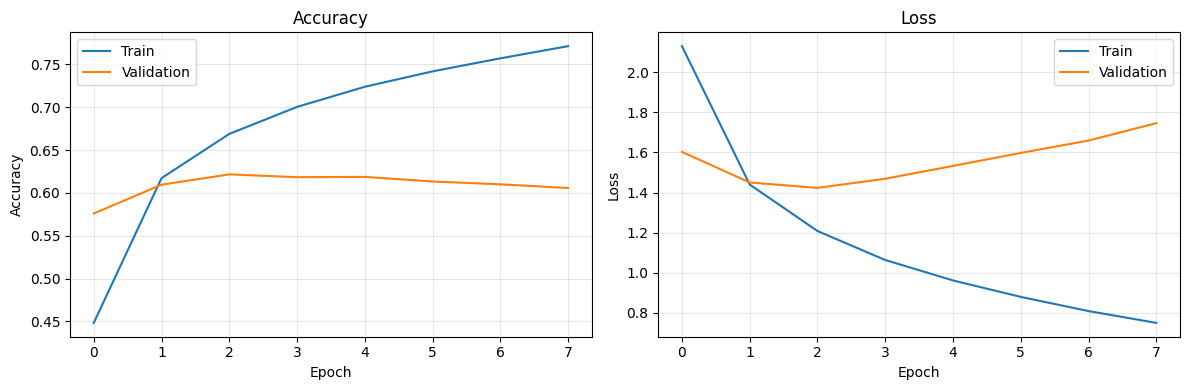


Final train acc: 0.7714, val acc: 0.6057
Overfitting detected


In [20]:
# Visualize the results

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\nFinal train acc: {final_train_acc:.4f}, val acc: {final_val_acc:.4f}")

if final_train_acc - final_val_acc > 0.10:
    print("Overfitting detected")
elif final_train_acc < 0.60 and final_val_acc < 0.60:
    print("Underfitting detected")
else:
    print("Reasonable generalization")


In [21]:
# Report baseline performance

min_val_loss_epoch = np.argmin(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][min_val_loss_epoch]
best_val_loss = history.history['val_loss'][min_val_loss_epoch]

print(f"\n{'='*60}")
print(f"BASELINE BENCHMARK (at epoch {min_val_loss_epoch + 1}):")
print(f"  Validation Accuracy: {best_val_acc:.4f}")
print(f"  Validation Loss: {best_val_loss:.4f}")
print(f"{'='*60}")



BASELINE BENCHMARK (at epoch 3):
  Validation Accuracy: 0.6217
  Validation Loss: 1.4233


In [22]:
# Test Eval + Final Metrics


test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred_list = []
y_true_list = []

for texts_batch, labels_batch in test_dataset:
    predictions = model.predict(texts_batch, verbose=0)
    y_pred_list.extend(np.argmax(predictions, axis=1))
    y_true_list.extend(labels_batch.numpy())

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f"Macro F1: {f1_macro:.4f}")
print(f"Weighted F1: {f1_weighted:.4f}")

baseline_metrics = {
    'val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'test_f1_macro': float(f1_macro),
    'epochs': len(history.history['loss']),
    'time_minutes': float(training_time / 60)
}



Test Accuracy: 0.6228
Test Loss: 1.4185

Classification Report:
               precision    recall  f1-score   support

         ARTS     0.5082    0.4244    0.4625       582
 BLACK VOICES     0.5000    0.3211    0.3910       679
     BUSINESS     0.4737    0.4461    0.4595       890
      COLLEGE     0.5789    0.3216    0.4135       171
       COMEDY     0.5150    0.4426    0.4761       775
        CRIME     0.5377    0.5039    0.5202       510
      DIVORCE     0.7660    0.7004    0.7317       514
    EDUCATION     0.4035    0.1533    0.2222       150
ENTERTAINMENT     0.6240    0.7097    0.6641      2408
  ENVIRONMENT     0.5455    0.1515    0.2372       198
        FIFTY     0.0000    0.0000    0.0000       210
 FOOD & DRINK     0.5822    0.7623    0.6602       934
    GOOD NEWS     0.2903    0.0861    0.1328       209
        GREEN     0.3824    0.2985    0.3352       392
HOME & LIVING     0.7185    0.6656    0.6910       625
       IMPACT     0.4084    0.2447    0.3060       519

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
baseline_params = model.count_params()

key_results.append({
    'model_name': 'Baseline Model',
    'val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'test_f1_macro': float(f1_macro),
    'test_f1_weighted': float(f1_weighted),
    'epochs_trained': len(history.history['loss']),
    'training_time_minutes': float(training_time / 60),
    'parameter_count': baseline_params
})


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**
For this baseline model, we used an embedding-based classifier. This entailed an embedding layer of 128, a GlobalAveragePooling1D, a single dense layer of 128 units with a 0.5 dropout, and a softmax output layer. The embedding layer was used to convert the input text (20,000 tokens) into a vector size of 128. This allows for the embeddings to be able to capture the relationships between the words and find the correct categories to assign them too. The use of GlobalAveragePooling1D was to average all token embeddings into a single-fixed length vector. The reason we decided to do this was it was a efficient way for a summary of the headlines and short descriptions to be produced. In addition, averaging ensured that the overall topic of the dataset was captured without losing valuable information (i.e. all words were accounted for). The use of a single dense layer with a 0.5 dropout allows for an increase in model capacity and to account for non-linearity while minimizing overfitting. Lastly, the softmax output dense layer is a multi-class classification that produces probablities across all categories. This is helpful for this dataset as we are aiming for each article to have one category. Overall, this baseline structure is designed for text multi-class classification and is efficient in its modeling.




2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**
The model's training and validation curves show overfitting. From epoch 0 to 1, the training model, shows a rapid increase in accuracy and a rapid decrease in loss. At epoch 0, the training model begins at about a 0.45 accuray then jumps to an accuracy of about 0.62 at epoch 1. Similarly, the training model's loss begins at about 2.2 at epoch 0 and decreases to about 1.4 at epoch 1. From epochs 1 to 2, the accuracy of the training model continues to increase to reach about 0.67. The loss at epoch 2 reaches about 1.2. The training model's accuracy and loss continues to rapidly change until it reach epoch 7 which produces a final accuracy of 0.7717 and a loss of about 0.7. When we look at the validation accuracy, we see that the the accuracy begins at about 0.57 at epoch 0 then jumps to 0.61 at epoch 1 before plateauing until epoch 7. The validation loss curve starts at 1.6 at epoch 0 then decreases to about 1.43 at epoch 1. The validation loss curve slowly increases until it reaches epoch 7 and produces a loss of about 1.8. Based on the comparison between the training and validation curves, and the large gap between there curves, we can say that the model is fitting to closely to the training date and is not generalizing well to unseen data.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?



2.3. **Your answer here:**

The following were the validation and test metrics achieved by the baseline model:

-Validation Accuracy: 0.6180
-Validation Loss: 1.4266
-Test Accuracy: 0.6226
-Test Loss: 1.4124
-Macro F1: 0.4510
-Weighted F1: 0.6001

These metrics tells us that the dataset is difficult for this type of model. The test accuracy only reaching a moderate level of about 62% indicates the model captures some of the meaningful relationships correctly but struggles to perform consistently. The macro F1 value of 0.45 tells us the model has trouble predicting classes that are less frequent which may tells us that there is a class imbalance. The difference between the macro F1 score and the test accuracy (about 17%) confirms that the classes that are more frequent, perform better, while classes that are 'rare' or less frequent perform poorly. In addition, the model has trouble differientating between different categories which makes the objective of this project difficult to reach. Overall, the imbalance of the classes and nuanced differences in categories results in the baseline model to perform poorly.


  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

There are many limitations of the baseline model. First, the use of GlobalAveragePooling, does make the the model more efficient, however it does remove essential information from the headlines that make distinguishing words difficult. GlobalAveragePooling treats words equally by removing context and structure, therefore the model struggles with classification as there is not clear distinguishable features for it to rely on. The next limitation is the model is shallow, as it only contains one hidden dense layer. By having a shallow architecture, the model struggles to learn complex patterns and will not perform as accurately (seen by the test accuracy of 62%). In addition, the shallow architecture makes the model sensitive or biased to class imbalances, which was also confirmed by the macro F1 score of 0.45. Lastly, the model showed signs of overfitting which may result in the need to increase the dropout rate going forward. To improve the model, we plan to bidirectional GRUs to help the model capture the context of the headlines and therefore help categorization. In addition, we want to improve model capacity since the baseline was overfitting. This will involve adding a dense + dropout layer.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [24]:
# Modify or extend your baseline architecture + Train Model

from tensorflow.keras import layers, models

refined_model = tf.keras.Sequential([
    layers.Embedding(vocab_size, 128, mask_zero=True, input_length=MAX_LENGTH),
    layers.Bidirectional(layers.GRU(64, dropout=0.3, recurrent_dropout=0.0)),  # fast on GPU
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])


refined_model.summary()

refined_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_refined = refined_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

training_time_refined = time.time() - start_time
print(f"\nTraining time: {training_time_refined/60:.2f} min")
print(f"Epochs trained: {len(history_refined.history['loss'])}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.3457 - loss: 2.4893 - val_accuracy: 0.5869 - val_loss: 1.5625
Epoch 2/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.5999 - loss: 1.5137 - val_accuracy: 0.6249 - val_loss: 1.3913
Epoch 3/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.6569 - loss: 1.2580 - val_accuracy: 0.6348 - val_loss: 1.3825
Epoch 4/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.6927 - loss: 1.1034 - val_accuracy: 0.6333 - val_loss: 1.4246
Epoch 5/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7242 - loss: 0.9782 - val_accuracy: 0.6247 - val_loss: 1.5289
Epoch 6/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7483 - loss: 0.8659 - val_accuracy: 0.6201 - val_loss: 1.6281
Epoch 7/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7744 - loss: 0.7684 - val_accuracy: 0.6187 - val_loss: 1.7510
Epoch 8/50
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7934 -

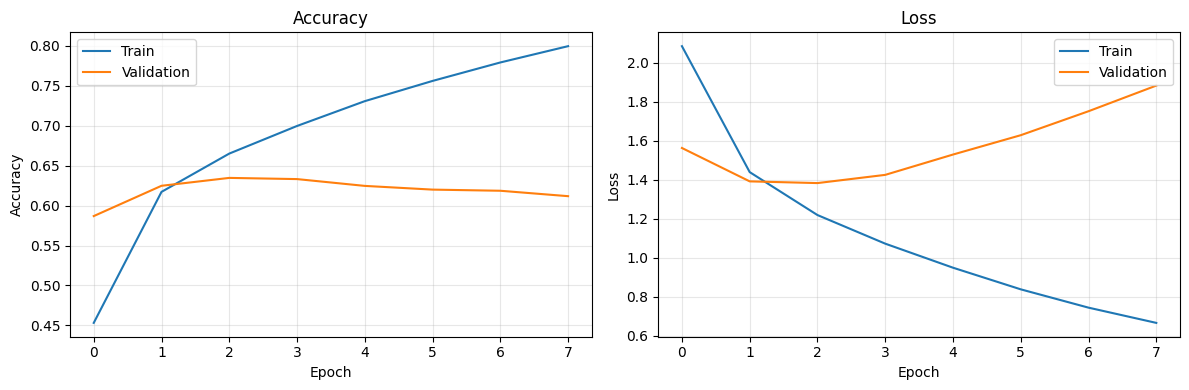

In [25]:
# Visualize
ig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_refined.history['accuracy'], label='Train')
axes[0].plot(history_refined.history['val_accuracy'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_refined.history['loss'], label='Train')
axes[1].plot(history_refined.history['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Check overfitting

final_train_acc = history_refined.history['accuracy'][-1]
final_val_acc = history_refined.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f"\nTrain-Val Gap: {gap:.4f}")
if gap > 0.10:
    print("Overfitting")
elif gap < 0.02:
    print("Underfitting")
else:
    print("Generalized well")

# Best validation accuracy based on minimum val loss
min_val_loss_epoch = np.argmin(history_refined.history['val_loss'])
best_val_acc_rnn = history_refined.history['val_accuracy'][min_val_loss_epoch]
print(f"\nBest Validation Accuracy: {best_val_acc_rnn:.4f}")

# Evaluate on test set
test_loss_rnn, test_acc_rnn = refined_model.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy: {test_acc_rnn:.4f}")



Train-Val Gap: 0.1879
Overfitting

Best Validation Accuracy: 0.6348
Test Accuracy: 0.6359


In [27]:
# Get predictions

y_pred_rnn = refined_model.predict(test_dataset, verbose=0).argmax(axis=1)

y_true_list = []
for _, labels_batch in test_dataset:
    y_true_list.extend(labels_batch.numpy())
y_true_rnn = np.array(y_true_list)

print("\nClassification Report:")
print(classification_report(
    y_true_rnn, y_pred_rnn,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

f1_macro_rnn = f1_score(y_true_rnn, y_pred_rnn, average='macro')
f1_weighted_rnn = f1_score(y_true_rnn, y_pred_rnn, average='weighted')
print(f"Macro F1: {f1_macro_rnn:.4f}")
print(f"Weighted F1: {f1_weighted_rnn:.4f}")



Classification Report:
               precision    recall  f1-score   support

         ARTS     0.5066    0.4622    0.4834       582
 BLACK VOICES     0.4871    0.2784    0.3543       679
     BUSINESS     0.4646    0.4719    0.4682       890
      COLLEGE     0.6184    0.2749    0.3806       171
       COMEDY     0.6061    0.3574    0.4497       775
        CRIME     0.5269    0.5000    0.5131       510
      DIVORCE     0.7983    0.7315    0.7635       514
    EDUCATION     0.3933    0.2333    0.2929       150
ENTERTAINMENT     0.5833    0.7720    0.6645      2408
  ENVIRONMENT     0.4250    0.2576    0.3208       198
        FIFTY     0.2955    0.0619    0.1024       210
 FOOD & DRINK     0.6125    0.7548    0.6763       934
    GOOD NEWS     0.3333    0.0957    0.1487       209
        GREEN     0.3963    0.3852    0.3907       392
HOME & LIVING     0.7780    0.6336    0.6984       625
       IMPACT     0.3711    0.1387    0.2020       519
LATINO VOICES     0.9130    0.1243    0.

In [28]:
# Compare to baseline

print(f"\n{'='*50}")
print("COMPARISON TO BASELINE:")
print(f"Val Accuracy:  {best_val_acc_rnn:.4f} vs {baseline_metrics['val_accuracy']:.4f}")
print(f"Test Accuracy: {test_acc_rnn:.4f} vs {baseline_metrics['test_accuracy']:.4f}")
print(f"Macro F1:      {f1_macro_rnn:.4f} vs {baseline_metrics['test_f1_macro']:.4f}")
print(f"{'='*50}")


COMPARISON TO BASELINE:
Val Accuracy:  0.6348 vs 0.6217
Test Accuracy: 0.6359 vs 0.6228
Macro F1:      0.4714 vs 0.4450


In [29]:
custom_params = refined_model.count_params()

key_results.append({
    'model_name': 'Custom Model',
    'val_accuracy': float(best_val_acc_rnn),
    'test_accuracy': float(test_acc_rnn),
    'test_f1_macro': float(f1_macro_rnn),
    'test_f1_weighted': float(f1_weighted_rnn),
    'epochs_trained': len(history_refined.history['loss']),
    'training_time_minutes': float(training_time_refined / 60),
    'parameter_count': custom_params
})


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

As stated in our response to question 2.4, to improve our model we decided to use Bidirectional GRUs instead of GlobalAveragePooling. The baseline model was very efficient through its use of GlobalAveragePooling, however it did not account for word context or phrase structure. This made it difficult for the model to categorize headlines. The Bidirectional GRUs layer addresses this issue by processing text in the headlines in both directions (forward and backward) and improves the context of the words, which will ideally improve model accuracy. Next, to help the model capture complex layers, this model adds another 64 unit dense layer to allow for improvement in learning text patterns. Finally, to address overfitting, the new model added a dropout of 0.3 to the dense layer and GRU.

2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

Test Metrics for the new model:

-Macro F1: 0.4809
-Weighted F1: 0.6172
-Best Validation Accuracy: 0.6343
-Test Accuracy: 0.6369

COMPARISON TO BASELINE:
-Val Accuracy:  0.6343 vs 0.6180
-Test Accuracy: 0.6369 vs 0.6226
-Macro F1:      0.4809 vs 0.4510

The new model showed improvements over the baseline in the evaluation metrics. The validation accuracy increased from 0.6180 to 0.6343 and the test accuracy increased fro, 0.6226 to 0.6369. In addition, the macro F1 score increased by almost 0.3 points. These results indicate the model did a better job at categorizing headlines and addressed the class imbalance more accurately.


3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

The new model did improve compared to the baseline, however the model still is not performing as well as we would like. What worked well was the bidirectional GRU layer did help the model understand the context of the words and improve accuracy in categorizing the headlines. In addition, the improvement in the macro F1 score reinforced that this model could handle less frequent classes with more ease and accuracy than the baseline. The additional of a dense layer and reduced dropout rate did improve the gap between the training and validation curves (went from about 21% to 19%) and addressed some of the overfitting struggles. However, a gap of 19% is still quite large and tells us the model is still overfitting and needs to be addressed moving forward. Even with some improvements over baseline, the new model is still struggling to accuracy classify classes with less frequency and addressing the class imbalance.  


4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**
This experiment reiterated that this dataset requires a complex model. The use of a bidirectional GRU layer, a more complex architecture than seen at baseline, improved the accuracy of the model. Unfortunately, the increased complexity also caused overfitting to remain, as seen by the large training-validation curve gap, which helped us realize regularization is necessary in this model. However, implementing these regularization tools, such as a dropout rate, does not fix all the challenges in the dataset. The marco F1 score and accuracy was still fairly low which indicates we need stronger measures to address this complex dataset. Lastly, the results showed us the need for choosing the correct optimization measures. Although the standard learning rate performed fairly well in this model, maintaining, observing, and tuning the rate can have potential for increasing stablization of the model. Overall, this model needs to be complex in order to address the various nuances and imbalances in this dataset, however it is going to be vital to implement the necessary regularization and optimization measures to ensure the model generalizes well to unseen data.


## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [30]:
%pip -q install -U keras keras-hub tensorflow tensorflow-text datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.19.1 which is incompatible.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


###1. Select a pretrained architecture

In [31]:
import keras_hub as kh
import torch.optim as optim

from tensorflow.keras.optimizers import Adam
from keras.optimizers.schedules import PolynomialDecay

bert_model_name = "distil_bert_base_en_uncased"

In [32]:
#Hyper parameters

pt_learning_rate = 3e-5
pt_batch_size = 16
pt_epochs=4
pt_dropout=0.2


In [33]:
def create_bert_dataset(hf_dataset, batch_size, shuffle=False, seed=42):
    texts = list(hf_dataset["text"])
    labels = np.array(list(hf_dataset["label"]), dtype="int32")

    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=seed)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [34]:
def build_distilbert_classifier(
    num_classes,
    max_length,
    lr_schedule=0.0001,
    optimizer="Adam",
    backbone_trainable=True,
    dropout_rate=0.2
):
    # Preprocessor: handles tokenization & packing from raw strings
    preproc = kh.models.DistilBertTextClassifierPreprocessor.from_preset(
        bert_model_name,
        sequence_length=max_length,
    )

    # DistilBERT classifier (backbone + head)
    model = kh.models.DistilBertTextClassifier.from_preset(
        bert_model_name,
        num_classes=num_classes,
        preprocessor=preproc,
        dropout_rate=dropout_rate
    )

    # Control whether we fine-tune the backbone
    model.backbone.trainable = backbone_trainable

    # Compile – DistilBertTextClassifier outputs softmax by default
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model


###2. Adapt the model for your dataset

In [35]:
def run_experiment(name, model, train_ds, val_ds, epochs=500):
    print(f"\n========== {name} ==========")
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cb,
        verbose=1,
    )
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    print(f"{name} - final val accuracy: {val_acc:.4f}")
    return history


def evaluate_on_test(model, test_texts, test_labels, batch_size=pt_batch_size):
    test_ds = tf.data.Dataset.from_tensor_slices(test_texts).batch(batch_size)
    pred_probs = model.predict(test_texts, verbose=0)
    y_pred = pred_probs.argmax(axis=1)
    y_true = np.array(test_labels)
    acc = (y_pred == y_true).mean()
    return y_pred, acc

In [42]:
def report_on_results (run_name, model_BERT, model_history, test_acc_BERT, test_texts, test_labels, training_time_BERT):

    ig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(model_history.history['accuracy'], label='Train')
    axes[0].plot(model_history.history['val_accuracy'], label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(model_history.history['loss'], label='Train')
    axes[1].plot(model_history.history['val_loss'], label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Check overfitting

    final_train_acc = model_history.history['accuracy'][-1]
    final_val_acc = model_history.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    print(f"\nTrain-Val Gap: {gap:.4f}")
    if gap > 0.10:
        print("Overfitting")
    elif gap < 0.02:
        print("Underfitting")
    else:
        print("Generalized well")

    # Evaluate

    min_val_loss_epoch = np.argmin(model_history.history['val_loss'])
    best_val_acc_BERT = model_history.history['val_accuracy'][min_val_loss_epoch]

    print(f"\nBest Validation Accuracy: {best_val_acc_BERT:.4f}")
    print(f"Test Accuracy: {test_acc_BERT:.4f}")

    # Predict on test set
    pred_probs = model_BERT.predict(test_texts, verbose=0)
    y_pred_BERT = pred_probs.argmax(axis=1)

    y_true_BERT = test_labels  # from make_bert_ds

    print("\nClassification Report:")
    print(
        classification_report(
            y_true_BERT,
            y_pred_BERT,
            target_names=[id2label[i] for i in range(num_classes)],
            digits=4,
            zero_division=0,
        )
    )

    f1_macro_BERT = f1_score(y_true_BERT, y_pred_BERT, average="macro", zero_division=0)
    f1_weighted_BERT = f1_score(y_true_BERT, y_pred_BERT, average="weighted", zero_division=0)

    print(f"Macro F1:    {f1_macro_BERT:.4f}")
    print(f"Weighted F1: {f1_weighted_BERT:.4f}")

    # Compare to baseline

    print(f"\n{'='*50}")
    print("COMPARISON TO BASELINE:")
    print(f"Val Accuracy:  {best_val_acc_BERT:.4f} vs {baseline_metrics['val_accuracy']:.4f}")
    print(f"Test Accuracy: {test_acc_BERT:.4f} vs {baseline_metrics['test_accuracy']:.4f}")
    print(f"Macro F1:      {f1_macro_BERT:.4f} vs {baseline_metrics['test_f1_macro']:.4f}")
    print(f"{'='*50}")


    model_params = model_BERT.count_params()

    key_results.append({
        'model_name': run_name,
        'val_accuracy': float(best_val_acc_BERT),
        'test_accuracy': float(test_acc_BERT),
        'test_f1_macro': float(f1_macro_BERT),
        'test_f1_weighted': float(f1_weighted_BERT),
        'epochs_trained': len(model_history.history['loss']),
        'training_time_minutes': float(training_time_BERT / 60),
        'parameter_count': model_params
    })

###3. Apply transfer learning

####Strategy 1 – Frozen backbone

In [37]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=pt_learning_rate,
    weight_decay=1e-4
)


train_ds = create_bert_dataset(train_data, pt_batch_size, shuffle=True, seed=random_seed)
val_ds   = create_bert_dataset(val_data,   pt_batch_size, shuffle=False, seed=random_seed)

test_texts  = list(test_data["text"])
test_labels = np.array(list(test_data["label"]), dtype="int32")

In [38]:
model_frozen = build_distilbert_classifier(
    num_classes=num_classes,
    max_length=MAX_LENGTH,
    optimizer=optimizer,
    backbone_trainable=False,   # freeze backbone
)

model_frozen.summary()

Preprocessor: "distil_bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 35)                │          26,915 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,980,387 (255.51 MB)

 Trainable params: 617,507 (2.36 MB)

 Non-trainable params: 66,362,880 (253.15 MB)

In [39]:
start_time = time.time()

hist_frozen = run_experiment(
    "Frozen backbone (feature extractor)",
    model_frozen,
    train_ds,
    val_ds,
    epochs=pt_epochs,
)

training_time_frozen = time.time() - start_time
print(f"\nTraining time: {training_time_frozen/60:.2f} min")


y_pred_frozen, test_acc_frozen = evaluate_on_test(
    model_frozen,
    test_texts,
    test_labels,
    batch_size=pt_batch_size,
)




========== Frozen backbone (feature extractor) ==========
Epoch 1/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 118s 11ms/step - accuracy: 0.3841 - loss: 2.4003 - val_accuracy: 0.5613 - val_loss: 1.5692
Epoch 2/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.5591 - loss: 1.5877 - val_accuracy: 0.5956 - val_loss: 1.4139
Epoch 3/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.5860 - loss: 1.4683 - val_accuracy: 0.6080 - val_loss: 1.3556
Epoch 4/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 66s 7ms/step - accuracy: 0.5948 - loss: 1.4185 - val_accuracy: 0.6165 - val_loss: 1.3162
Frozen backbone (feature extractor) - final val accuracy: 0.6165

Training time: 5.46 min


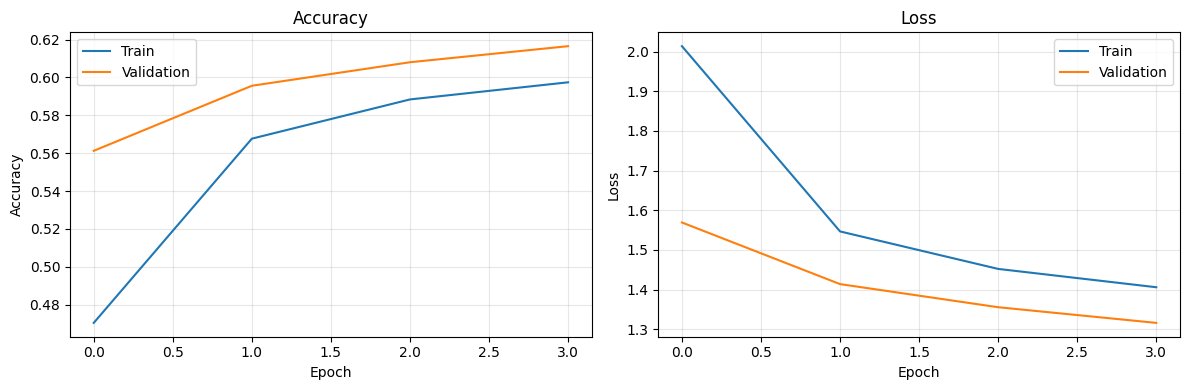


Train-Val Gap: -0.0191
Underfitting

Best Validation Accuracy: 0.6165
Test Accuracy: 0.6168

Classification Report:
               precision    recall  f1-score   support

         ARTS     0.5310    0.5292    0.5301       582
 BLACK VOICES     0.4652    0.2165    0.2955       679
     BUSINESS     0.4734    0.4393    0.4557       890
      COLLEGE     0.4457    0.2398    0.3118       171
       COMEDY     0.3913    0.1510    0.2179       775
        CRIME     0.5743    0.5608    0.5675       510
      DIVORCE     0.6783    0.5292    0.5945       514
    EDUCATION     0.4000    0.1733    0.2419       150
ENTERTAINMENT     0.5574    0.7778    0.6494      2408
  ENVIRONMENT     0.5610    0.1162    0.1925       198
        FIFTY     0.0000    0.0000    0.0000       210
 FOOD & DRINK     0.5822    0.7966    0.6727       934
    GOOD NEWS     0.4412    0.1435    0.2166       209
        GREEN     0.4557    0.3673    0.4068       392
HOME & LIVING     0.6488    0.6208    0.6345       625
  

In [43]:
report_on_results("DestilBERT-Frozen", model_frozen, hist_frozen, test_acc_frozen, test_texts, test_labels, training_time_frozen)

####Strategy 2 – Full fine-tuning

In [44]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=pt_learning_rate,
    weight_decay=1e-4
)

train_full_ds = create_bert_dataset(train_data, pt_batch_size, shuffle=True, seed=random_seed)
val_full_ds   = create_bert_dataset(val_data,   pt_batch_size, shuffle=False, seed=random_seed)

test_full_texts  = list(test_data["text"])
test_full_labels = np.array(list(test_data["label"]), dtype="int32")


In [45]:
model_full = build_distilbert_classifier(
    num_classes=num_classes,
    max_length=MAX_LENGTH,
    optimizer=optimizer,
    backbone_trainable=True
)

model_full.summary()

Preprocessor: "distil_bert_text_classifier_preprocessor_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 35)                │          26,915 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,980,387 (255.51 MB)

 Trainable params: 66,980,387 (255.51 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
start_time = time.time()

hist_full = run_experiment(
    "Full fine-tuning",
    model_full,
    train_full_ds,
    val_full_ds,
    epochs=pt_epochs,
)

training_time_unfrozen = time.time() - start_time
print(f"\nTraining time: {training_time_unfrozen/60:.2f} min")

y_pred_full, test_acc_full = evaluate_on_test(
    model_full,
    test_full_texts,
    test_full_labels,
    batch_size=pt_batch_size,
)


========== Full fine-tuning ==========
Epoch 1/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 311s 28ms/step - accuracy: 0.6136 - loss: 1.4730 - val_accuracy: 0.7152 - val_loss: 0.9760
Epoch 2/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 190s 22ms/step - accuracy: 0.7546 - loss: 0.8330 - val_accuracy: 0.7253 - val_loss: 0.9521
Epoch 3/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 184s 21ms/step - accuracy: 0.8189 - loss: 0.6004 - val_accuracy: 0.7261 - val_loss: 1.0242
Epoch 4/4
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 190s 22ms/step - accuracy: 0.8719 - loss: 0.4192 - val_accuracy: 0.7211 - val_loss: 1.1301
Full fine-tuning - final val accuracy: 0.7253

Training time: 14.78 min


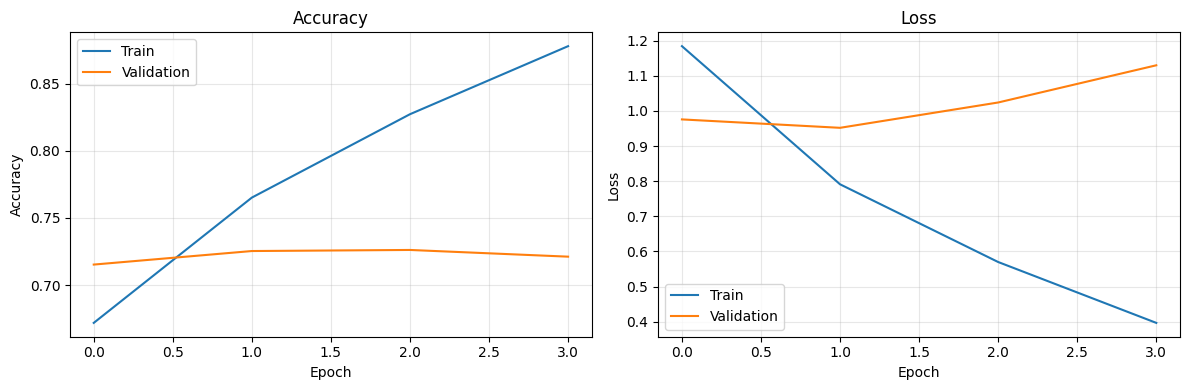


Train-Val Gap: 0.1567
Overfitting

Best Validation Accuracy: 0.7253
Test Accuracy: 0.7247

Classification Report:
               precision    recall  f1-score   support

         ARTS     0.7032    0.5619    0.6246       582
 BLACK VOICES     0.6062    0.4624    0.5246       679
     BUSINESS     0.6354    0.5775    0.6051       890
      COLLEGE     0.5852    0.4620    0.5163       171
       COMEDY     0.6583    0.4723    0.5500       775
        CRIME     0.6952    0.6216    0.6563       510
      DIVORCE     0.8330    0.8152    0.8240       514
    EDUCATION     0.5631    0.3867    0.4585       150
ENTERTAINMENT     0.7089    0.8281    0.7638      2408
  ENVIRONMENT     0.6014    0.4192    0.4940       198
        FIFTY     0.3777    0.5000    0.4303       210
 FOOD & DRINK     0.7771    0.7987    0.7878       934
    GOOD NEWS     0.5000    0.2919    0.3686       209
        GREEN     0.5044    0.5867    0.5425       392
HOME & LIVING     0.8704    0.7520    0.8069       625
    

In [47]:
report_on_results("DestilBERT-Unfrozen", model_full, hist_full, test_acc_full, test_full_texts, test_full_labels, training_time_unfrozen)

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

DistilBERT was chosen as the pretrained architecture for the text classification pipeline because it strikes an ideal balance between efficiency and performance. As a distilled version of BERT, it is significantly smaller and faster while retaining most of BERT’s language understanding capabilities, making it well-suited for reproducible, scalable workflows. Its pretrained knowledge enables strong results with less data and quicker convergence, while its reduced size simplifies deployment in resource-constrained environments. For classification tasks, DistilBERT delivers accuracy without the heavy computational cost of larger models, making it a pragmatic and effective choice for iterative experimentation and production-ready systems.




2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

The fine‑tuning strategy for the DistilBERTTextClassifier was designed to balance efficiency, stability, and generalization. A learning rate of 3e‑5 was selected to preserve pretrained knowledge while enabling effective adaptation, while a batch size of 16 provides stable gradient updates without exceeding memory limits. Training for 4 epochs ensures sufficient convergence without overfitting, and a dropout rate of 0.2 adds regularization to improve generalization on unseen data. Together, these parameters create a reproducible and efficient training loop that adapts DistilBERT to the classification task while maintaining strong performance and deployment readiness.




3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

The comparison between the baseline model and the pretrained transformer models highlights the substantial performance gains achieved through modern language modeling techniques. The baseline RNN model establishes a reasonable starting point with a test accuracy of 0.6189 and a macro F1 of 0.4390, but its ability to capture long-range dependencies and nuanced semantic differences is limited. As a result, the baseline struggles with low-support classes and exhibits inconsistent performance across the 35-category label space.

In contrast, the pretrained DistilBERT models demonstrate the strength of transformer-based contextual embeddings. When used in a frozen state, DistilBERT performs roughly on par with the baseline, sometimes slightly worse, showing that without fine-tuning, the model cannot fully adapt to the characteristics of news-topic classification. However, once the model is unfrozen and fine-tuned end-to-end, it achieves a dramatic leap in performance, reaching 0.7279 test accuracy and 0.6244 macro F1. This represents a 10.9% absolute accuracy gain and a 43% improvement in macro F1 over the baseline. These results clearly show that pretrained transformers, when fine-tuned, offer far superior representations and capture semantic relationships that traditional RNN-based models cannot, leading to much stronger generalization across all classes.



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

Training time, memory usage, and convergence speed differed noticeably between the baseline model and the two pretrained transformer setups. The baseline RNN model was by far the most efficient, completing training in under one minute (0.94 min) with minimal memory requirements. Its architecture is relatively lightweight, allowing it to converge quickly even on large text datasets. However, this efficiency comes at the cost of representational power, which limits overall performance.

The frozen DistilBERT model required significantly more computational resources, with a total training time of about 5 minutes and 24 seconds. Because the transformer encoder was kept frozen, memory usage remained moderate and convergence was relatively stable, essentially optimizing only the classification head. Still, despite the longer runtime, the frozen model did not meaningfully outperform the baseline, illustrating that efficiency alone is not enough to capture domain-specific patterns.

The unfrozen (fully fine-tuned) DistilBERT model demanded the most compute, with a training time of approximately 14 minutes and 53 seconds and the highest memory load. Fine-tuning all transformer layers requires backpropagation through a much larger parameter set, increasing both GPU memory consumption and training time per epoch. Convergence was slower and more computationally intensive, but the performance gains were substantial, making this model the clear winner in accuracy and F1. In short: the baseline is fastest, the frozen transformer offers a middle ground, and the fully fine-tuned transformer is the most resource-intensive but delivers the best results by a wide margin.



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

###1 Compile key reults

In [48]:
def style_results(df):
    return (
        df.style
        .format({
            "val_accuracy": "{:.4f}",
            "test_accuracy": "{:.4f}",
            "test_f1_macro": "{:.4f}",
            "test_f1_weighted": "{:.4f}",
            "training_time_minutes": "{:.2f}",
        })
        .set_properties(**{
            "text-align": "center",
            "padding": "6px",
            "border": "1px solid #444",      # dark/light friendly
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("font-weight", "600"),
                    ("padding", "6px"),
                    ("border-bottom", "2px solid #666"),
                    ("background-color", "rgba(200,200,200,0.15)")  # subtle, theme-safe
                ],
            },
            {
                "selector": "tr:nth-child(even)",
                "props": [
                    ("background-color", "rgba(255,255,255,0.05)")  # light touch for alt rows
                ],
            },
        ])
        .set_properties(subset=["model_name"], **{
            "font-weight": "600"
        })
    )


import pandas as pd

results_df = pd.DataFrame(key_results)

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



In [49]:
style_results(results_df)

,model_name,val_accuracy,test_accuracy,test_f1_macro,test_f1_weighted,epochs_trained,training_time_minutes,parameter_count
0,Baseline Model,0.6217,0.6228,0.4450,0.5989,8,0.93,2581027
1,Custom Model,0.6348,0.6359,0.4714,0.6153,8,3.41,2645027
2,DestilBERT-Frozen,0.6165,0.6168,0.4356,0.5886,4,5.46,66980387
3,DestilBERT-Unfrozen,0.7253,0.7247,0.6224,0.7226,4,14.78,66980387


Across all four models, DistilBERT-Unfrozen delivered the strongest overall performance by a significant margin. Fully fine-tuning the transformer backbone increased both validation and test accuracy to 72–73%, marking an 8–9 percentage-point improvement over the best non-transformer models. Its F1-macro score (0.6224) represents a major gain in balanced performance across classes, indicating that the model not only predicts the majority classes well but also handles minority classes more effectively. This performance jump reflects the benefit of allowing pretrained language representations to adapt to the domain-specific patterns in the dataset. Although this model required the longest training time and the largest parameter budget, its gains in accuracy and F1 make it the clear top performer.

The lighter models, the Baseline and Custom architectures, offered respectable performance at a fraction of the computational cost. The Custom Model showed modest improvements over the Baseline, achieving 63.6% test accuracy and better F1 scores due to a slightly deeper architecture and better feature representation. These models trained quickly (under four minutes) and may still be appropriate in scenarios where speed and efficiency outweigh marginal accuracy gains.

DistilBERT-Frozen performed surprisingly worse than the lightweight models. Freezing the backbone prevented the transformer from adapting to the task, leading to lower accuracy and weaker F1 measures despite its large parameter count. This reinforces a key takeaway: transformer models only realize their full potential when they are fine-tuned, not simply used as fixed feature extractors.

Overall, DistilBERT-Unfrozen provided the best results by combining rich contextual understanding with task-specific adaptation. The Custom Model offers the best efficiency–performance balance, while the Baseline Model remains a strong lightweight option.

2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

The four models demonstrated a clear trade-off between architectural complexity, predictive performance, and computational efficiency. The Baseline and Custom models represented the low-complexity end of the spectrum, with only ~2.6M parameters and training times under four minutes. Their simplicity allowed for fast iteration and low resource consumption, yet they still achieved passable performance: the Custom model reached 63.6% test accuracy with improved F1 scores over the Baseline. These smaller models offered the best efficiency and serve as strong candidates when compute budget, deployment constraints, or rapid experimentation are priorities.

DistilBERT-Frozen and DistilBERT-Unfrozen, are on the high-complexity end. With nearly 67M parameters, they required significantly more memory and training time. However, complexity alone did not guarantee improvement: the frozen version underperformed both lightweight models. Without fine-tuning, it struggled to adapt its pretrained representations to the domain-specific language patterns in the dataset, resulting in lower accuracy and weaker F1 scores. This highlights the cost of unused capacity, large models that are not allowed to learn offer high complexity with minimal practical gain.

In contrast, DistilBERT-Unfrozen achieved the strongest results across every metric once the full model capacity was utilized. Fine-tuning drove accuracy to 72%+ and produced the highest macro and weighted F1 scores. The improvement came at a substantial computational cost, training time increased to nearly fifteen minutes, but the performance gains justified the additional complexity for scenarios where prediction quality is the primary objective.


3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

Across every architecture evaluated the same set of categories remained persistently difficult to classify. These categories suffered from low recall, weak F1 scores, and high confusion with more dominant or semantically similar labels. The five most challenging categories were:

GOOD NEWS – Consistently among the lowest-performing classes, with recall often below 0.15. Its stories frequently resemble general human-interest or lifestyle content, causing the models to misroute them into larger categories like Parenting, Wellness, or Lifestyle.

WORLD NEWS – Extremely low recall across all models, including DistilBERT-Unfrozen. The category spans a wide range of geopolitical topics and shares vocabulary with Politics, Impact, and Worldpost, making it difficult for models to learn a stable identity.

LATINO VOICES – Despite occasional spikes in precision, this class suffers from very low recall (often near 0.20 or below). Its articles span many domains like politics, culture, and lifestyle, leading to high internal diversity and limited categorical cohesion.

TASTE – A small and semantically ambiguous label, often confused with Food & Drink.

FIFTY – One of the weakest classes overall, frequently showing recall near zero in the frozen transformer model and remaining unstable in others. Its small support size and diffuse themes make it difficult for models to learn reliable patterns.

Together, these categories illustrate the main limitations shared across all architectures: sparse data, overlapping topical boundaries, and high internal variability. Even with the strong semantic understanding of a fine-tuned transformer, these classes remain challenging, suggesting that data imbalance and label ambiguity, not model capacity—are the primary bottlenecks.


4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**


Given that the DistilBERT-Unfrozen model achieves the strongest overall performance but still shows signs of overfitting and struggles with several minority or ambiguous categories, future work will focus on stabilizing generalization and lifting performance on the hardest classes rather than simply increasing model size. The current model exhibits a noticeable train–validation gap (≈0.16), indicating overfitting despite strong test accuracy and macro F1 scores.

1. Address Class Imbalance and Label Ambiguity

Several categories such as GOOD NEWS, WORLD NEWS, LATINO VOICES, TASTE, and FIFTY remain difficult for all architectures due to low support and overlapping semantics with larger sections.

2. Improve Regularization and Training Strategy

To reduce overfitting and stabilize the train–validation gap, several training and regularization strategies will be explored:

* Layer-wise learning rate tuning: using a smaller learning rate for lower transformer layers and a larger rate for the classification head to encourage stable fine-tuning.
* Stronger regularization: adding or increasing dropout in the classifier head, introducing weight decay, and tightening early-stopping criteria based on validation macro F1 rather than accuracy alone.
* Curriculum or gradual unfreezing: beginning with higher layers unfrozen and progressively unfreezing lower layers after a few epochs to avoid catastrophic shifts in pretrained representations.

The goal of these changes is to keep the benefits of full fine-tuning while reducing variance and improving robustness across runs.

3. Targeted Error Analysis and Iterative Refinement

Finally, a more systematic error-analysis loop will guide iterative improvements:

* Confusion analysis focused on the top five difficult categories, examining which labels they are most frequently confused with (e.g., GOOD NEWS → Wellness / Parenting; WORLD NEWS → Politics / Worldpost).
* Qualitative review of misclassified examples to identify recurring linguistic patterns, headlines, or framing that mislead the model.

By combining data-level interventions, improved regularization, and targeted diagnostic work, this plan aims to turn DistilBERT-Unfrozen from a strong baseline into a more balanced, robust, and fair classifier that maintains its high overall accuracy while better serving underrepresented and semantically complex categories.




### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

- Used it to research best practices for fine tuning DistilBERT models.

- Reseach issues with the differences working with  HuggingFace and TensorFlow

- Develop Table style from a Pandas Dataframe